In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from typing import Optional, TypedDict, Literal, Dict, List, Any, Union, get_args, Iterable
from dataclasses import dataclass, field
from trade.datamanager.utils.model import (
    LoadRequest,
    _load_model_data_timeseries,
    DivType,
    VolatilityModel,
    OptionPricingModel,
)
from trade.helpers.helper import time_distance_helper
from trade.datamanager.base import BaseDataManager
from trade.datamanager.config import OptionDataConfig
from trade.datamanager.result import _OptionModelResultsBase, Result
from trade.datamanager.result import (
    VolatilityResult,
    ForwardResult,
    RatesResult,
    OptionSpotResult,
    SpotResult,
    DividendsResult,
)
from trade.datamanager._enums import (
    SeriesId,
    GreekType,
    OptionSpotEndpointSource,
    Interval,
    ArtifactType,
    RealTimeFallbackOption,
)
from trade.datamanager.vars import LOADED_NAMES
from trade.datamanager.utils.model import ModelResultPack
from enum import Enum
from trade.datamanager.utils.cache import _check_cache_for_timeseries_data_structure
from trade.datamanager.utils.date import DATE_HINT
from trade.optionlib.greeks.numerical.binomial import binomial_tree_greeks
from trade.optionlib.greeks.numerical.black_scholes import vectorized_black_scholes_greeks
from trade.optionlib.assets.dividend import vectorized_discrete_pv, get_vectorized_continuous_dividends, vector_convert_to_time_frac
from trade.datamanager.utils.date import sync_date_index, is_available_on_date, to_datetime
from trade.helpers.helper import change_to_last_busday
from trade.datamanager import DividendDataManager
from datetime import datetime
from trade.helpers.Logging import setup_logger
from trade.datamanager.utils.vol_helpers import (
    _prepare_vol_calculation_setup,
    _handle_cache_for_vol,
    _merge_and_cache_vol_result,
)
from trade.datamanager import (
    DividendDataManager,
    SpotDataManager,
    OptionSpotDataManager,
    VolDataManager,
    RatesDataManager,
    BaseDataManager,
    ForwardDataManager,
    GreekDataManager,
    assert_synchronized_model,
)
from trade.optionlib.assets.dividend import get_vectorized_dividend_scehdule, get_div_histories
from trade.optionlib.pricing.binomial import vector_crr_binomial_pricing
from trade.optionlib.pricing.black_scholes import black_scholes_vectorized
from trade.datamanager.vars import load_name, clear_loaded_names
from trade.optionlib.assets.forward import vectorized_forward_continuous, vectorized_forward_discrete
logger = setup_logger(__name__)
CONFIG = OptionDataConfig()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


2026-02-01 00:07:25 trade.helpers.Logging INFO: Logging Root Directory: /Users/chiemelienwanisobi/cloned_repos/QuantTools/logs
2026-02-01 00:07:25 [test] trade.helpers.clear_cache INFO: No expired caches to delete on 2026-02-01.
2026-02-01 00:07:30 [test] dbase.DataAPI.ThetaData.proxy INFO: Refreshed proxy URL: http://54.205.248.219:5500/thetadata
2026-02-01 00:07:30 [test] dbase.DataAPI.ThetaData.proxy INFO: Using Proxy URL: http://54.205.248.219:5500/thetadata
2026-02-01 00:07:30 [test] dbase.DataAPI.ThetaData INFO: Using V2 of the ThetaData API


Scheduled Data Requests will be saved to: /Users/chiemelienwanisobi/cloned_repos/QuantTools/module_test/raw_code/DataManagers/scheduler/requests.jsonl
2026-02-01 00:07:34 [test] DataManager.py CRITICAL: Using ProcessSaveManager for saving data.
Fetching rates data from yfinance directly during market hours
YF.download() has changed argument auto_adjust default to True


In [2]:
@dataclass
class TheoreticalPriceResult(_OptionModelResultsBase):
    timeseries: Optional[pd.Series] = None

    def __repr__(self) -> str:
        return super().__repr__() 

TheoreticalPriceResult()

TheoreticalPriceResult(symbol=None, strike=None, expiration=None, right=None, model_price=<ModelPrice.MIDPOINT: 'midpoint'>)

In [3]:
from trade.datamanager._enums import ModelPrice


def _create_load_request(
    ## Requied parameters to ensure correct data is loaded
    start_date: DATE_HINT,
    end_date: DATE_HINT,
    symbol: str,
    expiration: DATE_HINT,
    strike: float,
    right: str,
    dividend_type: DivType,
    market_model: OptionPricingModel,
    endpoint_source: OptionSpotEndpointSource,
    model_price: ModelPrice,
    is_scenario_load: bool = False,
    *,
    ## Optional pre-loaded data. If not provided, will be loaded.
    s: Optional[SpotResult] = None,
    r: Optional[RatesResult] = None,
    f: Optional[ForwardResult] = None,
    d: Optional[DividendsResult] = None,
    vol: Optional[VolatilityResult] = None,
    option_spot: Optional[OptionSpotResult] = None,
    undo_adjust: bool = True,
    
) -> LoadRequest:
        """Create a LoadRequest specifying which market data to load for greek calculation.

        Internal utility that determines which data sources need to be loaded based on:
        1. Which data is already provided (pre-loaded)
        2. Which pricing model is being used (BSM needs forwards, binomial needs spot)

        Args:
            start_date: First valuation date (YYYY-MM-DD string or datetime).
            end_date: Last valuation date (YYYY-MM-DD string or datetime).
            expiration: Option expiration date (YYYY-MM-DD string or datetime).
            strike: Strike price of the option.
            right: Option type ('c' for call, 'p' for put).
            dividend_type: Dividend treatment type (DISCRETE or CONTINUOUS).
            market_model: Pricing model (BSM or BINOMIAL).
            endpoint_source: Option data source (ORATS, HIST, QUOTE).
            model_price: Which price to use (CLOSE, OPEN, MIDPOINT).
            s: Optional pre-loaded spot data. If None, will be loaded.
            r: Optional pre-loaded rates data. If None, will be loaded.
            f: Optional pre-loaded forward data. If None, will be loaded (BSM only).
            d: Optional pre-loaded dividend data. If None, will be loaded.
            vol: Optional pre-loaded volatility data. If None, will be loaded.
            undo_adjust: If True, uses split-adjusted prices.

        Returns:
            LoadRequest object with flags indicating which data sources to load.

        Examples:
            >>> # Internal usage - creates request to load all data
            >>> request = greek_mgr._create_load_request(
            ...     start_date="2025-01-01",
            ...     end_date="2025-01-31",
            ...     expiration="2025-06-20",
            ...     strike=150.0,
            ...     right="c",
            ...     dividend_type=DivType.DISCRETE,
            ...     market_model=OptionPricingModel.BSM,
            ...     endpoint_source=OptionSpotEndpointSource.HIST,
            ...     model_price=ModelPrice.CLOSE
            ... )
            >>> # request.load_forward = True (BSM needs forwards)
            >>> # request.load_spot = True (no spot provided)
            >>> # request.load_vol = True (no vol provided)
        """
        if is_scenario_load:
            ## For scenario loads, always load all data to ensure completeness.
            load_spot = s is None
            load_vol = vol is None
            load_dividend = d is None
            load_rates = r is None
            option_spot = option_spot is None
            load_forward = False ## Not needed for scenario load
        else:
            
            ## For regular loads, determine based on provided data and model needs.
            load_spot = (s is None) and (market_model == OptionPricingModel.BINOMIAL)
            load_vol = (vol is None)
            load_dividend = (d is None)
            load_rates = (r is None)
            option_spot = False  ## Not needed for greek calculation
            load_forward = (market_model == OptionPricingModel.BSM) and (f is None)

        req = LoadRequest(
            symbol=symbol,
            start_date=start_date,
            end_date=end_date,
            expiration=expiration,
            strike=strike,
            right=right,
            dividend_type=dividend_type,
            endpoint_source=endpoint_source,
            vol_model=VolatilityModel.MARKET,
            model_price=model_price,
            market_model=market_model,
            
            ## Load spot only if missing.
            load_spot=load_spot,
            
            ## Load forward only if missing and using BSM model. Binomial uses spot price.
            load_forward=load_forward,
            load_vol=load_vol,
            load_dividend=load_dividend,
            load_rates=load_rates,
            
            ## Not needed for greek calculation
            load_option_spot=option_spot,
            undo_adjust=undo_adjust,
        )
        return req

In [22]:
def get_option_theoretical_price(
    symbol: str,
    start_date: DATE_HINT,
    end_date: DATE_HINT,
    strike: float,
    expiration: DATE_HINT,
    right: Literal['c', 'p'],
    *,
    market_model: Optional[OptionPricingModel] = None,
    endpoint_source: OptionSpotEndpointSource = None,
    dividend_type: Optional[DivType] = None,
    vol: Optional[VolatilityResult] = None,
    model_price: Optional[ModelPrice] = None,
    spot: Optional[SpotResult] = None,
    f: Optional[ForwardResult] = None,
    r: Optional[RatesResult] = None,
    d: Optional[DividendsResult] = None,
    undo_adjust: bool = True,
    n_steps: Optional[int] = None,
) -> TheoreticalPriceResult:
    """Calculate theoretical option prices over a date range using specified pricing model.

    Args:
        symbol (str): Underlying asset symbol.
        start_date (DATE_HINT): Start date for the calculation.
        end_date (DATE_HINT): End date for the calculation.
        strike (float): Option strike price.
        expiration (DATE_HINT): Option expiration date.
        right (Literal['c', 'p']): 'c' for call, 'p' for put option.
        market_model (Optional[OptionPricingModel], optional): Pricing model to use. Defaults to None.
        endpoint_source (OptionSpotEndpointSource, optional): Source for option spot data. Defaults to None.
        dividend_type (Optional[DivType], optional): Type of dividend adjustment. Defaults to None.
        vol (Optional[VolatilityModel], optional): Volatility model to use. Defaults to None.
        spot (Optional[float], optional): Spot price of the underlying asset. Defaults to None.
        f (Optional[ForwardResult], optional): Forward price of the underlying asset. Defaults to None.
        r (Optional[RatesResult], optional): Risk-free interest rate. Defaults to None.
        option_spot (Optional[OptionSpotResult], optional): Spot price of the option. Defaults to None.
        n_steps (Optional[int], optional): Number of steps for binomial model. Defaults to None.
    Returns:
        TheoreticalPriceResult: Result object containing theoretical prices time series.
    """
    market_model = market_model or CONFIG.option_model
    endpoint_source = endpoint_source or CONFIG.option_spot_endpoint_source
    dividend_type = dividend_type or CONFIG.dividend_type
    vol_model = CONFIG.volatility_model
    model_price = model_price or CONFIG.model_price
    n_steps = n_steps or CONFIG.n_steps
    result = TheoreticalPriceResult()
    result.dividend_type = dividend_type
    result.market_model = market_model
    result.model_price = model_price
    result.vol_model = vol_model
    result.endpoint_source = endpoint_source
    result.expiration = to_datetime(expiration)
    result.right = right
    result.strike = strike
    result.symbol = symbol
    result.rt = False
    result.undo_adjust = undo_adjust

    # Create load request to determine which data to load
    load_request = _create_load_request(
        symbol=symbol,
        start_date=start_date,
        end_date=end_date,
        expiration=expiration,
        strike=strike,
        right=right,
        dividend_type=dividend_type,
        market_model=market_model,
        endpoint_source=endpoint_source,
        model_price=model_price,
        s=spot,
        f=f,
        r=r,
        vol=vol,
        is_scenario_load=False,
    )

    # Load required market data
    packet = _load_model_data_timeseries(load_request)

    # Extract time series data, using provided data if available
    s, r, vol, d, f = (
        packet.spot.timeseries if not packet.spot.is_empty() else spot.timeseries if spot is not None else pd.Series(dtype=float),
        packet.rates.timeseries if not packet.rates.is_empty() else r.timeseries if r is not None else pd.Series(dtype=float),
        packet.vol.timeseries if not packet.vol.is_empty() else vol.timeseries if vol is not None else pd.Series(dtype=float),
        packet.dividend.timeseries if not packet.dividend.is_empty() else d.timeseries if d is not None else pd.Series(dtype=float),
        packet.forward.timeseries if not packet.forward.is_empty() else f.timeseries if f is not None else pd.Series(dtype=float),
    )
    

    # Use loaded data to calculate theoretical prices
    if market_model == OptionPricingModel.BINOMIAL:
        s, vol, r, d = sync_date_index(s, vol, r, d)
        t = time_distance_helper(start=s.index, end = [expiration] * len(s))
        if dividend_type == DivType.DISCRETE:
            discrete = vector_convert_to_time_frac(
                schedules=d.values,
                valuation_dates=d.index,
                end_dates=[to_datetime(expiration)] * len(s),
            )
            dividend_yield = [0.0] * len(s)
        else:
            discrete = [()] * len(s)
            dividend_yield = d.values

        prices = vector_crr_binomial_pricing(
            K = [strike] * len(s),
            T = t,
            sigma = vol.values,
            r = r.values,
            N = [n_steps] * len(s),
            S0 = s.values,
            right = [right] * len(s),
            american = [True] * len(s),
            dividend_yield=dividend_yield,
            dividends=discrete,
            dividend_type=[dividend_type.value] * len(s),
        )
        result.timeseries = pd.Series(data=prices, index=s.index, name='theoretical_price', dtype=float)
        return result
    
    elif market_model == OptionPricingModel.BSM:
        f, vol, r, d = packet.forward.timeseries, packet.vol.timeseries, packet.rates.timeseries, packet.dividend.timeseries
        f, vol, r, d = sync_date_index(f, vol, r, d)
        t = time_distance_helper(start=f.index, end = [expiration] * len(f))
        prices = black_scholes_vectorized(
            F = f.values,
            K = [strike] * len(f),
            T = t,
            r = r.values,
            sigma = vol.values,
            option_type = [right] * len(f),
        )
        result.timeseries = pd.Series(data=prices, index=f.index, name='theoretical_price', dtype=float)
        return result


    



In [5]:

DEFAULT_SCENARIOS = [0.9, 0.95, 1.0, 1.05, 1.1]
DEFAULT_VOL_SCENARIOS = [-0.2, -0.1, 0.0, 0.1, 0.2]
@dataclass
class ScenariosResult(_OptionModelResultsBase):
    grid: Optional[pd.DataFrame] = None
    spot_scenarios: List[float] = field(default_factory=lambda: DEFAULT_SCENARIOS)
    vol_scenarios: List[float] = field(default_factory=lambda: DEFAULT_VOL_SCENARIOS)
    def __repr__(self) -> str:
        return super().__repr__()

In [6]:
_OptionModelResultsBase().__dict__

{'model_input_keys': None,
 'rt': False,
 'symbol': None,
 'strike': None,
 'expiration': None,
 'right': None,
 'model_price': <ModelPrice.MIDPOINT: 'midpoint'>,
 'endpoint_source': None,
 'market_model': None,
 'vol_model': None,
 'dividend_type': None,
 'undo_adjust': None}

In [7]:
s = 100
div = 0.5
y = div/s

print(f"y = {y}")

shock = 0.9
new_s = s * shock
new_y = div/new_s

print(f"new_y = {new_y}")
print(f"Shock applied on original y: {y / shock}")

y = 0.005
new_y = 0.005555555555555556
Shock applied on original y: 0.005555555555555556


In [8]:
def _adjust_div_yield_for_spot_shock(
    shock: float,
    div: float,
) -> float:
    """Adjust dividend yield based on spot price shock for continuous dividends."""
    adjusted_div = div / shock
    return adjusted_div

In [9]:
from itertools import product
def _calculate_binomial_scenarios(
    base_prices: pd.Series,
    s: pd.Series,
    strike: float,
    expiration: DATE_HINT,
    right: Literal['c', 'p'],
    vol: pd.Series,
    r: pd.Series,
    dividend_type: DivType,
    dividends: pd.Series,
    spot_scenarios: List[float] = None,
    vol_scenarios: List[float] = None,
    return_pnl: bool = False,
    return_pnl_in_pct: bool = False,
    n_steps: int = None,
    prettify_columns: bool = False,
) -> pd.DataFrame:
    """Calculate spot price scenarios using binomial model.

    Args:
        base_prices (pd.Series): Base theoretical prices time series.
        s (pd.Series): Spot prices time series.
        strike (float): Option strike price.
        expiration (DATE_HINT): Option expiration date.
        right (Literal['c', 'p']): 'c' for call, 'p' for put option.
        vol (pd.Series): Volatility time series.
        r (pd.Series): Risk-free interest rate time series.
        dividend_type (DivType): Type of dividend adjustment.
        spot_scenarios (List[float]): List of spot price multipliers to generate scenarios. Spot scenarios are multiplied to the spot price to generate different spot price levels.
        vol_scenarios: List[float]: List of volatility multipliers to generate scenarios. Vol scenarios are added to the volatility to generate different volatility levels.
        n_steps (int): Number of steps for binomial model.

    Returns:
        pd.DataFrame: DataFrame containing spot price scenarios.
    """
    assert any([spot_scenarios, vol_scenarios]), "At least one of spot_scenarios or vol_scenarios must be provided."
    assert len(vol.index) == 1, "Spot scenarios calculation only supports single-date series."
    
    ## Default scenarios
    if spot_scenarios is None:
        spot_scenarios = [1.0]
    if vol_scenarios is None:
        vol_scenarios = [0.0]
    
    ## Sync all data to same index
    s, vol, r, dividends, base_prices = sync_date_index(s, vol, r, dividends, base_prices)
    scenario_prices: Dict[str, pd.Series] = {}

    ## Define pricing function for reuse
    def price_func(scenario_spot: pd.Series, 
                   scenario_vol: pd.Series,
                   expiration: DATE_HINT,
                   right: Literal['c', 'p'],
                   strike: float,
                   dividend_type: DivType,
                   dividends: pd.Series,
                   n_steps: int,
                   r: pd.Series,
                   ) -> pd.Series:
        t = time_distance_helper(start=scenario_spot.index, end = [expiration] * len(scenario_spot))
        if dividend_type == DivType.DISCRETE:
            discrete = vector_convert_to_time_frac(
                schedules=dividends.values,
                valuation_dates=scenario_spot.index,
                end_dates=[to_datetime(expiration)] * len(scenario_spot),
            )
            dividend_yield = [0.0] * len(scenario_spot)
        else:
            discrete = [()] * len(scenario_spot)
            dividend_yield = dividends.values

        prices = vector_crr_binomial_pricing(
            K = [strike] * len(scenario_spot),
            T = t,
            sigma = scenario_vol.values,
            r = r.values,
            N = [n_steps] * len(scenario_spot),
            S0 = scenario_spot.values,
            right = [right] * len(scenario_spot),
            american = [True] * len(scenario_spot),
            dividend_yield=dividend_yield,
            dividends=discrete,
            dividend_type=[dividend_type.value] * len(scenario_spot),
        )
        return pd.Series(data=prices, index=scenario_spot.index, name='theoretical_price', dtype=float)
    

    ## Calculate prices for each scenario
    scenarios = list(product(spot_scenarios, vol_scenarios))
    for spot_mult, vol_add in scenarios:
        scenario_spot = s * spot_mult
        scenario_vol = vol + vol_add
        if dividend_type == DivType.CONTINUOUS:
            
            adjusted_dividends = _adjust_div_yield_for_spot_shock(spot_mult, dividends)
        else:
            adjusted_dividends = dividends

        prices = price_func(scenario_spot, scenario_vol, expiration, right, strike, dividend_type, adjusted_dividends, n_steps, r)
        prices = prices[0]
        if return_pnl:
            prices = prices - base_prices[0]
            if return_pnl_in_pct:
                prices = prices / base_prices[0]
        scenario_prices.setdefault(spot_mult, []).append(prices)



    df =  pd.DataFrame(scenario_prices, index=vol_scenarios)
    if prettify_columns:
        df.columns = [f"Spot x{col:.2f}" for col in df.columns]
        df.index = [f"Vol {'+' if idx > 0 else ''}{idx:.2%}" for idx in df.index]
    return df
    

In [10]:
def _calculate_bsm_scenarios(
    base_prices: pd.Series,
    s: pd.Series,
    strike: float,
    expiration: DATE_HINT,
    right: Literal['c', 'p'],
    vol: pd.Series,
    r: pd.Series,
    dividend_type: DivType,
    pv_divs: pd.Series = None,
    q_factor: pd.Series = None,
    spot_scenarios: List[float] = None,
    vol_scenarios: List[float] = None,
    return_pnl: bool = False,
    return_pnl_in_pct: bool = False,
    prettify_columns: bool = False,
) -> pd.DataFrame:
    """Calculate spot price scenarios using Black-Scholes-Merton model.

    Args:
        base_prices (pd.Series): Base theoretical prices time series.
        s (pd.Series): Spot prices time series.
        strike (float): Option strike price.
        expiration (DATE_HINT): Option expiration date.
        right (Literal['c', 'p']): 'c' for call, 'p' for put option.
        vol (pd.Series): Volatility time series.
        r (pd.Series): Risk-free interest rate time series.
        dividend_type (DivType): Type of dividend adjustment.
        spot_scenarios (List[float]): List of spot price multipliers to generate scenarios. Spot scenarios are multiplied to the spot price to generate different spot price levels.
        vol_scenarios: List[float]: List of volatility multipliers to generate scenarios. Vol scenarios are added to the volatility to generate different volatility levels.

    Returns:
        pd.DataFrame: DataFrame containing spot price scenarios.
    """
    assert any([spot_scenarios, vol_scenarios]), "At least one of spot_scenarios or vol_scenarios must be provided."
    assert len(vol.index) == 1, "Spot scenarios calculation only supports single-date series."
    
    ## Default scenarios
    if spot_scenarios is None:
        spot_scenarios = [1.0]
    if vol_scenarios is None:
        vol_scenarios = [0.0]

    if dividend_type == DivType.CONTINUOUS:
        assert q_factor is not None, "For continuous dividends, q_factor must be provided."
        dividends = q_factor
    else:
        assert pv_divs is not None, "For discrete dividends, pv_divs must be provided."
        dividends = pv_divs
    
    ## Sync all data to same index
    s, vol, r, dividends, base_prices = sync_date_index(s, vol, r, dividends, base_prices)
    scenario_prices: Dict[str, pd.Series] = {}

    ## Define pricing function for reuse
    def price_func(scenario_spot: pd.Series, 
                   scenario_vol: pd.Series,
                   expiration: DATE_HINT,
                   right: Literal['c', 'p'],
                   strike: float,
                   ) -> pd.Series:
        t = time_distance_helper(start=scenario_spot.index, end = [expiration] * len(scenario_spot))
        if dividend_type == DivType.CONTINUOUS:
            F = vectorized_forward_continuous(
                S = scenario_spot.values,
                r = r.values,
                q_factor = dividends.values,
                T = t,
            )
        else:
            F = vectorized_forward_discrete(
                S = scenario_spot.values,
                r = r.values,
                pv_divs = dividends.values,
                T = t,
            )
        prices = black_scholes_vectorized(
            F = F,
            K = [strike] * len(scenario_spot),
            T = t,
            r = r.values,
            sigma = scenario_vol.values,
            option_type = [right] * len(scenario_spot),
        )
        return pd.Series(data=prices, index=scenario_spot.index, name='theoretical_price', dtype=float)
    
    ## Calculate prices for each scenarios
    scenarios = list(product(spot_scenarios, vol_scenarios))
    for spot_mult, vol_add in scenarios:
        scenario_spot = s * spot_mult
        scenario_vol = vol + vol_add

        prices = price_func(scenario_spot, scenario_vol, expiration, right, strike)
        prices = prices[0]
        if return_pnl:
            prices = prices - base_prices[0]
            if return_pnl_in_pct:
                prices = prices / base_prices[0]
        scenario_prices.setdefault(spot_mult, []).append(prices)

    df =  pd.DataFrame(scenario_prices, index=vol_scenarios)
    if prettify_columns:
        df.columns = [f"Spot x{col:.2f}" for col in df.columns]
        df.index = [f"Vol {'+' if idx > 0 else ''}{idx:.2%}" for idx in df.index]
    return df

In [15]:
def calculate_scenarios(
    symbol: str,
    as_of: DATE_HINT,
    strike: float,
    expiration: DATE_HINT,
    right: Literal["c", "p"],
    spot_scenarios: Optional[List[float]] = None,
    vol_scenarios: Optional[List[float]] = None,
    *,
    market_model: Optional[OptionPricingModel] = None,
    endpoint_source: OptionSpotEndpointSource = None,
    dividend_type: Optional[DivType] = None,
    vol: Optional[VolatilityResult] = None,
    model_price: Optional[ModelPrice] = None,
    spot: Optional[SpotResult] = None,
    option_spot: Optional[OptionSpotResult] = None,
    r: Optional[RatesResult] = None,
    d: Optional[DividendsResult] = None,
    undo_adjust: bool = True,
    n_steps: Optional[int] = None,
    prettify_columns: bool = False,
    return_pnl: bool = False,
    return_pnl_in_pct: bool = False,
) -> ScenariosResult:
    """Calculate spot price scenarios for an option over a date range using specified pricing model.

    Args:
        symbol (str): Underlying asset symbol.
        as_of (DATE_HINT): Date for the calculation.
        strike (float): Option strike price.
        expiration (DATE_HINT): Option expiration date.
        right (Literal['c', 'p']): 'c' for call, 'p' for put option.
        market_model (Optional[OptionPricingModel], optional): Pricing model to use. Defaults to None.
        endpoint_source (OptionSpotEndpointSource, optional): Source for option spot data. Defaults to None.
        dividend_type (Optional[DivType], optional): Type of dividend adjustment. Defaults to None.
        vol (Optional[VolatilityResult], optional): Volatility model to use. Defaults to None.
        spot (Optional[float], optional): Spot price of the underlying asset. Defaults to None.
        f (Optional[float], optional): Forward price of the underlying asset. Defaults to None.
        r (Optional[float], optional): Risk-free interest rate. Defaults to None.
        n_steps (Optional[int], optional): Number of steps for binomial model. Defaults to None.
        default_scenarios (Optional[List[float]], optional): List of spot price multipliers to generate scenarios. Defaults to None.

    Returns:
        SpotScenariosResult: Result object containing spot price scenarios time series.
    """
    market_model = market_model or CONFIG.option_model
    endpoint_source = endpoint_source or CONFIG.option_spot_endpoint_source
    dividend_type = dividend_type or CONFIG.dividend_type
    vol_model = vol or CONFIG.volatility_model
    model_price = model_price or CONFIG.model_price
    n_steps = n_steps or CONFIG.n_steps
    spot_scenarios = spot_scenarios or DEFAULT_SCENARIOS
    vol_scenarios = vol_scenarios or DEFAULT_VOL_SCENARIOS
    result = ScenariosResult()
    
    result.dividend_type = dividend_type
    result.market_model = market_model
    result.model_price = model_price
    result.vol_model = vol_model
    result.endpoint_source = endpoint_source
    result.expiration = to_datetime(expiration)
    result.right = right
    result.strike = strike
    result.symbol = symbol
    result.rt = False
    result.undo_adjust = undo_adjust
    result.spot_scenarios = spot_scenarios
    result.vol_scenarios = vol_scenarios

    # Create load request to determine which data to load
    load_request = _create_load_request(
        symbol=symbol,
        start_date=as_of,
        end_date=as_of,
        expiration=expiration,
        strike=strike,
        right=right,
        dividend_type=dividend_type,
        market_model=market_model,
        endpoint_source=endpoint_source,
        model_price=model_price,
        s=spot,
        r=r,
        d=d,
        vol=vol,
        option_spot=option_spot,
        is_scenario_load=True,
    )
    
    # Load required market data
    packet = _load_model_data_timeseries(load_request)
    
    s, r, vol, base_prices, d = (
        packet.spot.timeseries if not packet.spot.is_empty() else spot.timeseries,
        packet.rates.timeseries if not packet.rates.is_empty() else r.timeseries,
        packet.vol.timeseries if not packet.vol.is_empty() else vol.timeseries,
        packet.option_spot.price if not packet.option_spot.is_empty() else option_spot.price,
        packet.dividend.timeseries if not packet.dividend.is_empty() else d.timeseries,
    )
    # Use loaded data to calculate theoretical prices
    if market_model == OptionPricingModel.BINOMIAL:
        s, vol, r, d, base_prices = sync_date_index(s, vol, r, d, base_prices)
        df = _calculate_binomial_scenarios(
            base_prices=base_prices,
            s=s,
            strike=strike,
            expiration=expiration,
            right=right,
            vol=vol,
            r=r,
            dividend_type=dividend_type,
            dividends=d,
            spot_scenarios=spot_scenarios,
            vol_scenarios=vol_scenarios,
            n_steps=n_steps,
            prettify_columns=prettify_columns,
            return_pnl=return_pnl,
            return_pnl_in_pct=return_pnl_in_pct,
        )
        result.grid = df
        return result
    
    ## BSM model
    elif market_model == OptionPricingModel.BSM:
        s, vol, r, d, base_prices = sync_date_index(s, vol, r, d, base_prices)
        if dividend_type == DivType.DISCRETE:
            pv_divs = vectorized_discrete_pv(
                schedules=d.values,
                _valuation_dates=s.index,
                _end_dates=[to_datetime(expiration)] * len(s),
                r=r.values,
            )
            pv_divs = pd.Series(data=pv_divs, index=s.index, name='pv_dividends', dtype=float)
            q_factor = None
        else:
            pv_divs = None
            q_factor = get_vectorized_continuous_dividends(
                div_rates=d.values,
                _valuation_dates=s.index,
                _end_dates=[to_datetime(expiration)] * len(s),
            )
            q_factor = pd.Series(data=q_factor, index=s.index, name='q_factor', dtype=float)
        df = _calculate_bsm_scenarios(
            base_prices=base_prices,
            s=s,
            strike=strike,
            expiration=expiration,
            right=right,
            vol=vol,
            r=r,
            dividend_type=dividend_type,
            pv_divs=pv_divs,
            q_factor=q_factor,
            spot_scenarios=spot_scenarios,
            vol_scenarios=vol_scenarios,
            prettify_columns=prettify_columns,
            return_pnl=return_pnl,
            return_pnl_in_pct=return_pnl_in_pct,
        )
        result.grid = df
        return result

In [16]:
pd.options.display.float_format = '{:.2f}'.format

In [17]:
symbol = "SBUX"
expiration = "2026-09-18"
right = "C"
strike = 100.0
ts_start = "2025-01-01"
ts_end = "2026-01-28"


In [20]:
res = calculate_scenarios(
    symbol=symbol,
    as_of="2025-06-20",
    strike=strike,
    expiration=expiration,
    right=right.lower(),
    market_model=OptionPricingModel.BINOMIAL,
    dividend_type=DivType.DISCRETE,
    n_steps=50,
    prettify_columns=True,
    return_pnl=True,
    return_pnl_in_pct=False,
)

2026-02-01 00:54:20 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-02-01 00:54:20 [test] trade.datamanager.dividend INFO: Using provided dividend_type: DivType.DISCRETE
2026-02-01 00:54:20 [test] trade.datamanager.dividend INFO: Fetching discrete dividend schedule timeseries for SBUX from 2025-06-20 00:00:00 to 2025-06-20 00:00:00 with maturity 2026-09-18 00:00:00
2026-02-01 00:54:20 [test] trade.datamanager.dividend INFO: Cache hit for discrete schedule timeseries key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1
2026-02-01 00:54:20 [test] trade.datamanager.dividend INFO: Cache fully covers requested date range for timeseries. Key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1
2026-02-01 00:54:20 [test] trade.datamanager.rates INF

In [21]:
res.grid

,Spot x0.90,Spot x0.95,Spot x1.00,Spot x1.05,Spot x1.10
Vol -20.00%,-10.34,-9.52,-8.14,-6.13,-3.51
Vol -10.00%,-7.64,-6.04,-4.10,-1.87,0.79
Vol 0.00%,-4.23,-2.21,-0.09,2.46,5.10
Vol +10.00%,-0.53,1.64,4.03,6.71,9.39
Vol +20.00%,3.15,5.41,8.14,10.88,13.62


In [ ]:
dm = OptionSpotDataManager(symbol=symbol)
market = dm.get_option_spot_timeseries(
    start_date=ts_start,
    end_date=ts_end,
    expiration=expiration,
    strike=strike,
    right=right.lower(),
    endpoint_source=OptionSpotEndpointSource.QUOTE,
    model_price=ModelPrice.MIDPOINT,
)

2026-01-31 23:27:30 [test] trade.datamanager.utils INFO: Using cached date range for 2025-01-01 00:00:00 - 2026-01-28 00:00:00 and option tick SBUX20260918C100
2026-01-31 23:27:30 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: symbol:SBUX|interval:eod|artifact_type:option_spot|series_id:hist|endpoint_source:QUOTE|expiration:20260918T000000|right:C|strike:100
2026-01-31 23:27:30 [test] trade.datamanager.utils INFO: Sanitizing data from 2025-05-23 00:00:00 to 2026-01-28 00:00:00...
2026-01-31 23:27:30 [test] trade.datamanager.option_spot INFO: Cache hit for option spot timeseries key: symbol:SBUX|interval:eod|artifact_type:option_spot|series_id:hist|endpoint_source:QUOTE|expiration:20260918T000000|right:C|strike:100


In [ ]:
p = get_option_theoretical_price(
    symbol=symbol,
    start_date=ts_start,
    end_date=ts_end,
    strike=strike,
    expiration=expiration,
    right=right.lower(),
    market_model=OptionPricingModel.BSM,
    endpoint_source=OptionSpotEndpointSource.QUOTE,
    dividend_type=DivType.DISCRETE,
    vol=None,
    model_price=ModelPrice.MIDPOINT,
    n_steps = 500
)

2026-01-31 23:30:38 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-01-31 23:30:38 [test] trade.datamanager.dividend INFO: Using provided dividend_type: DivType.DISCRETE
2026-01-31 23:30:38 [test] trade.datamanager.dividend INFO: Fetching discrete dividend schedule timeseries for SBUX from 2025-01-01 00:00:00 to 2026-01-28 00:00:00 with maturity 2026-09-18 00:00:00


2026-01-31 23:30:38 [test] trade.datamanager.dividend INFO: No cache found for discrete schedule timeseries key: symbol:SBUX|interval:eod|artifact_type:divs|series_id:hist|current_state:SCHEDULE_TIMESERIES|lookback_years:1|maturity:2026-09-18|method:CONSTANT|undo_adjust:1. Building from scratch.
2026-01-31 23:30:38 [test] trade.datamanager.vars INFO: Timeseries for SBUX already loaded.
2026-01-31 23:30:38 [test] trade.datamanager.dividend INFO: Cache hit for key: symbol:SBUX|interval:na|artifact_type:divs|series_id:hist|current_state:SCHEDULE|lookback_years:1|method:CONSTANT|vendor:YFINANCE
2026-01-31 23:30:38 [test] trade.datamanager.dividend INFO: Cache partially covers requested date range. Key: symbol:SBUX|interval:na|artifact_type:divs|series_id:hist|current_state:SCHEDULE|lookback_years:1|method:CONSTANT|vendor:YFINANCE. Fetching missing data.
2026-01-31 23:30:42 [test] trade.optionlib.assets.dividend INFO: Using dual projection method for ticker SBUX
2026-01-31 23:30:42 [test] t

<Axes: xlabel='datetime'>

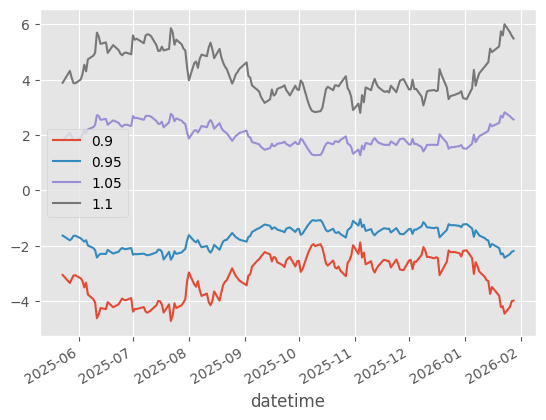

In [ ]:
t.plot()

In [ ]:
p.timeseries

datetime
2025-05-23    7.451125
2025-05-27    8.498988
2025-05-28    7.873432
2025-05-29    7.674288
2025-05-30    7.673466
                ...   
2026-01-22    8.923519
2026-01-23    9.298345
2026-01-26    8.650853
2026-01-27    7.974164
2026-01-28    8.225831
Name: theoretical_price, Length: 171, dtype: float64

<Axes: xlabel='datetime'>

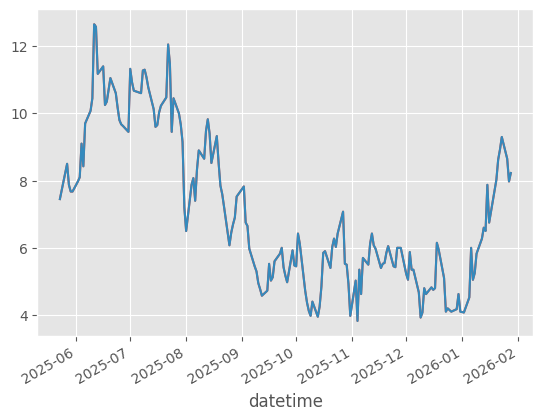

In [ ]:
p.timeseries.plot()
market.price.plot()

In [ ]:
market.timeseries


,open,high,low,close,volume,bid_size,closebid,ask_size,closeask,midpoint,weighted_midpoint
datetime,,,,,,,,,,,
2025-05-23,0.0,8.700,0.0,7.450,0.0,401.0,6.80,325.0,8.10,7.450,7.381956
2025-05-26,0.0,0.000,0.0,0.000,0.0,0.0,0.00,0.0,0.00,0.000,0.000000
2025-05-27,0.0,8.925,0.0,8.500,0.0,364.0,7.95,304.0,9.05,8.500,8.450599
2025-05-28,0.0,9.025,0.0,7.875,0.0,414.0,7.50,212.0,8.25,7.875,7.753994
2025-05-29,0.0,8.500,0.0,7.675,0.0,55.0,7.05,738.0,8.30,7.675,8.213304
...,...,...,...,...,...,...,...,...,...,...,...
2026-01-22,0.0,9.575,0.0,8.925,0.0,649.0,8.00,742.0,9.85,8.925,8.986844
2026-01-23,0.0,9.550,0.0,9.300,0.0,579.0,8.90,353.0,9.70,9.300,9.203004
2026-01-26,0.0,9.250,0.0,8.650,0.0,598.0,8.20,571.0,9.10,8.650,8.639607
